# Reproducing Noise-Level Logic from `make_traces_pair.py`

This notebook reproduces the **same noise generation method** used by
`reusable/make_traces_pair.py` and `TraceSimulator.NoiseGenerator`, then visualizes:

1. How noise level is determined from config (`noise_type`, `noise_power`, `sampling_frequency`).
2. How white/pink/custom noise traces are generated.
3. What "same noise level" means in this implementation.
4. Why custom PSD behaves differently with respect to `noise_power`.

Goal: make the method transparent and validate whether generated traces are at comparable noise level.


In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display

# TraceSimulator package path used by make_traces_pair.py environment
sys.path.insert(0, '/home/dwong/software/TraceSimulator')
from TraceSimulator.NoiseGenerator import NoiseGenerator

CFG_PATH = Path('/home/dwong/DELight_mtr/PCA_dev/reusable/PCA_config.yaml')
cfg = yaml.safe_load(CFG_PATH.read_text())

print('config path:', CFG_PATH)
print('noise_type:', cfg['noise_type'])
print('noise_power:', cfg['noise_power'])
print('sampling_frequency:', cfg['sampling_frequency'])
print('trace_samples:', cfg['trace_samples'])


config path: /home/dwong/DELight_mtr/PCA_dev/reusable/PCA_config.yaml
noise_type: /ceph/dwong/delight_conf/new/noise_psd_xray.npy
noise_power: 33.2
sampling_frequency: 3906250
trace_samples: 32768


## Exact Method Used by `NoiseGenerator`

From `TraceSimulator/NoiseGenerator.py`, noise is generated as:

- `f = rfftfreq(N, d=1/fs)`
- `norm = 0.5 * noise_power * normalize(noise_type, f) * fs * N`
- `psd = norm * spectrum(noise_type, f)`
- custom noise special handling:
  - `psd /= (0.5 * noise_power)`
  - `psd[1:...] *= 0.5`
- `A = sqrt(psd)`
- random phase Fourier bins `A * exp(i*phi)`
- inverse RFFT gives time noise trace.

So we can reconstruct the target PSD shape from config and compare to generated traces.


In [3]:
def _set_spectra():
    spectra = {
        'white': lambda f: np.ones(len(f)),
        'blue': lambda f: f,
        'violet': lambda f: f ** 2,
        'brownian': lambda f: 1 / np.where(f == 0, float('inf'), f ** 2),
        'pink': lambda f: 1 / np.where(f == 0, float('inf'), f),
    }
    normalize = {
        'white': lambda f: 1.0 / (np.max(f) - np.min(f)),
        'blue': lambda f: 2.0 / (np.max(f) ** 2 - np.min(f) ** 2),
        'violet': lambda f: 3.0 / (np.max(f) ** 3 - np.min(f) ** 3),
        'brownian': lambda f: 1.0 / (1.0 / np.sort(f)[1] - 1.0 / np.max(f)),
        'pink': lambda f: 1.0 / (np.log(np.max(f)) - np.log(np.sort(f)[1])),
    }
    return spectra, normalize


def build_target_psd_like_noise_generator(config, noise_type):
    fs = float(config['sampling_frequency'])
    N = int(config['trace_samples'])
    noise_power = float(config['noise_power'])

    f = np.fft.rfftfreq(N, d=1.0 / fs)
    spectra, normalize = _set_spectra()

    if noise_type in spectra:
        spec = spectra[noise_type](f)
        norm = 0.5 * noise_power * normalize[noise_type](f) * fs * N
        psd = norm * spec
        return f, psd

    # custom path: load PSD from file and apply same transform as NoiseGenerator
    path = Path(noise_type)
    arr = np.load(path)
    # file format expected by NoiseGenerator: [freq, psd]
    freq_data = arr[0]
    psd_data = arr[1]
    psd_interp = np.interp(f, freq_data, psd_data, left=psd_data[0], right=psd_data[-1])

    # replicate NoiseGenerator steps for custom
    norm = 0.5 * noise_power * fs * N
    psd = norm * psd_interp
    psd /= (0.5 * noise_power)
    hi = N // 2 + 1 - (N + 1) % 2
    psd[1:hi] *= 0.5
    return f, psd


for nt in ['white', 'pink', cfg['noise_type']]:
    f, psd = build_target_psd_like_noise_generator(cfg, nt)
    print(nt, 'target_psd bins:', len(psd), 'min/max', float(np.min(psd)), float(np.max(psd)))


white target_psd bins: 16385 min/max 1087897.6 1087897.6
pink target_psd bins: 16385 min/max 0.0 1836768662.691846
/ceph/dwong/delight_conf/new/noise_psd_xray.npy target_psd bins: 16385 min/max 211551.05156908437 175879516.52697593


In [4]:
def generate_noise_batch(config, noise_type, n_draws=200):
    c = dict(config)
    c['noise_type'] = noise_type
    ng = NoiseGenerator(c)
    N = int(c['trace_samples'])
    arr = np.array([ng.generate_noise(N) for _ in range(n_draws)])
    return arr


def periodogram_one_sided(x, fs):
    # Returns one-sided PSD estimate consistent with rfft bins
    x = np.asarray(x)
    N = x.shape[-1]
    X = np.fft.rfft(x)
    P = (np.abs(X) ** 2) / (fs * N)
    if N % 2 == 0:
        P[..., 1:-1] *= 2.0
    else:
        P[..., 1:] *= 2.0
    f = np.fft.rfftfreq(N, d=1.0 / fs)
    return f, P


def summarize_noise(arr):
    var = np.var(arr, axis=1)
    rms = np.sqrt(np.mean(arr**2, axis=1))
    return {
        'var_mean': float(np.mean(var)),
        'var_std': float(np.std(var)),
        'rms_mean': float(np.mean(rms)),
        'rms_std': float(np.std(rms)),
    }


fs = float(cfg['sampling_frequency'])
N = int(cfg['trace_samples'])
noise_types = ['white', 'pink', cfg['noise_type']]

samples = {}
rows = []
for nt in noise_types:
    arr = generate_noise_batch(cfg, nt, n_draws=200)
    samples[nt] = arr
    stats = summarize_noise(arr)
    rows.append({'noise_type': nt, **stats})

summary_df = pd.DataFrame(rows)
summary_df


,noise_type,var_mean,var_std,rms_mean,rms_std
0,white,33.198464,0.000370,5.761854,0.000045
1,pink,35.174746,0.000036,5.930830,0.000003
2,/ceph/dwong/delight_conf/new/noise_psd_xray.npy,33.145143,0.000073,5.764211,0.005026


## Interpreting Noise Level Statistically (No FFT Needed for Area)

For each event we use:
- `noise = noisy - clean` (residual is the noise itself)
- residual mean
- residual standard deviation (`std`)
- residual variance (`var = std^2`)
- PSD-area proxy from time domain (`psd_area_proxy = var` for near-zero-mean noise)

So for scale checks, we can compare `std` / `var` / `psd_area_proxy` across many events directly,
without needing FFT-based PSD integration.


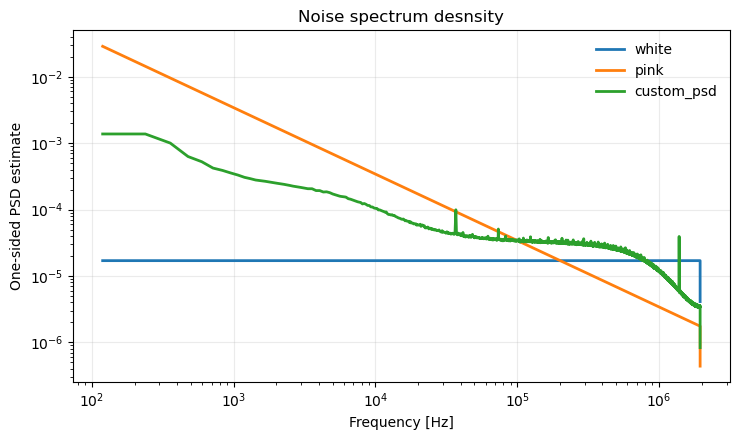

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))

labels = []
for nt in noise_types:
    labels.append(nt if nt in ['white', 'pink'] else 'custom_psd')

for nt, lab in zip(noise_types, labels):
    f, P = periodogram_one_sided(samples[nt], fs)
    Pm = np.mean(P, axis=0)
    ax.loglog(f[1:], Pm[1:], linewidth=2.0, label=lab)

ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('One-sided PSD estimate')
ax.set_title('Noise spectrum desnsity')
ax.grid(alpha=0.25)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


In [6]:
# Removed by request: sensitivity-to-noise_power scan.
print('Skipping noise_power sensitivity scan. Using many-event residual statistics from real traces below.')


Skipping noise_power sensitivity scan. Using many-event residual statistics from real traces below.


## Reproduce `make_traces_pair.py` Additive Process (QP-Sum Consistent)

For `*_pair_qp_sum_*.h5`, production does **not** add one noise stream to an already-summed trace.

It does this instead:
- start from per-QP-channel clean traces
- add independent channel-wise noise
- sum channels to form the QP-sum trace

So to compare MMC vs white vs pink fairly in QP-sum space, white/pink must be synthesized with the same channel-wise-then-sum procedure.


In [7]:
def _make_noise_generators(config):
    white_cfg = dict(config)
    white_cfg['noise_type'] = 'white'
    pink_cfg = dict(config)
    pink_cfg['noise_type'] = 'pink'
    return NoiseGenerator(white_cfg), NoiseGenerator(pink_cfg)


def _add_noise(noise_gen, clean_traces):
    noisy = np.empty_like(clean_traces, dtype=np.float32)
    for ch in range(clean_traces.shape[0]):
        noise = noise_gen.generate_noise(clean_traces.shape[1]).astype(np.float32, copy=False)
        noisy[ch] = clean_traces[ch] + noise
    return noisy


def _residual_metrics(noise_1d):
    n = np.asarray(noise_1d, dtype=np.float64)
    mu = float(np.mean(n))
    var = float(np.var(n))
    std = float(np.sqrt(var))
    rms = float(np.sqrt(np.mean(n ** 2)))
    return {
        'mean': mu,
        'std': std,
        'var': var,
        'rms': rms,
        'psd_area_proxy': var,  # for zero-mean process, PSD area ~= variance
    }


RNG_SEED = 20260304
N_VAR_EVENTS = 80
PLOT_START = 0
PLOT_SAMPLES = 2500
rng = np.random.default_rng(RNG_SEED)

pair_qp_file = Path('/ceph/dwong/trigger_samples/PCA_QP/main/NR_traces_energy_500_pair_batch_0000.h5')
pair_sum_file = Path('/ceph/dwong/trigger_samples/PCA_QP/main/NR_traces_energy_500_pair_qp_sum_batch_0000.h5')

white_gen, pink_gen = _make_noise_generators(cfg)
rows = []

if pair_qp_file.exists():
    import h5py
    with h5py.File(pair_qp_file, 'r') as f:
        clean_ds = f['traces_clean']
        mmc_ds = f['traces_MMC']
        n_events, n_qp_channels, n_samples = clean_ds.shape

        event_idx = int(rng.integers(0, n_events))
        clean_qp = np.asarray(clean_ds[event_idx], dtype=np.float32)
        mmc_qp = np.asarray(mmc_ds[event_idx], dtype=np.float32)

        noisy_white_qp = _add_noise(white_gen, clean_qp)
        noisy_pink_qp = _add_noise(pink_gen, clean_qp)

        clean = clean_qp.sum(axis=0, dtype=np.float64)[None, :].astype(np.float32, copy=False)
        mmc = mmc_qp.sum(axis=0, dtype=np.float64)[None, :].astype(np.float32, copy=False)
        noisy_white = noisy_white_qp.sum(axis=0, dtype=np.float64)[None, :].astype(np.float32, copy=False)
        noisy_pink = noisy_pink_qp.sum(axis=0, dtype=np.float64)[None, :].astype(np.float32, copy=False)

        k = min(N_VAR_EVENTS, n_events)
        sampled_event_idx = np.sort(rng.choice(n_events, size=k, replace=False))
        for ei in sampled_event_idx:
            c_qp = np.asarray(clean_ds[int(ei)], dtype=np.float32)
            m_qp = np.asarray(mmc_ds[int(ei)], dtype=np.float32)

            c_sum = c_qp.sum(axis=0, dtype=np.float64).astype(np.float32, copy=False)
            m_sum = m_qp.sum(axis=0, dtype=np.float64).astype(np.float32, copy=False)
            w_sum = _add_noise(white_gen, c_qp).sum(axis=0, dtype=np.float64).astype(np.float32, copy=False)
            p_sum = _add_noise(pink_gen, c_qp).sum(axis=0, dtype=np.float64).astype(np.float32, copy=False)

            for model, noise in [
                ('MMC', m_sum - c_sum),
                ('white', w_sum - c_sum),
                ('pink', p_sum - c_sum),
            ]:
                m = _residual_metrics(noise)
                rows.append({'event_idx': int(ei), 'model': model, **m})

    source = f'{pair_qp_file.name} (QP-sum consistent)'
    expected_sum_var = float(cfg['noise_power']) * float(n_qp_channels)

elif pair_sum_file.exists():
    import h5py
    with h5py.File(pair_sum_file, 'r') as f:
        clean_ds = f['traces_clean']
        mmc_ds = f['traces_MMC']
        n_events, n_channels, n_samples = clean_ds.shape

        event_idx = int(rng.integers(0, n_events))
        clean = np.asarray(clean_ds[event_idx], dtype=np.float32)
        mmc = np.asarray(mmc_ds[event_idx], dtype=np.float32)

        noisy_white = _add_noise(white_gen, clean)
        noisy_pink = _add_noise(pink_gen, clean)

        k = min(N_VAR_EVENTS, n_events)
        sampled_event_idx = np.sort(rng.choice(n_events, size=k, replace=False))
        for ei in sampled_event_idx:
            c = np.asarray(clean_ds[int(ei)], dtype=np.float32)
            m = np.asarray(mmc_ds[int(ei)], dtype=np.float32)
            w = _add_noise(white_gen, c)
            p = _add_noise(pink_gen, c)

            for model, noise in [
                ('MMC', m[0] - c[0]),
                ('white', w[0] - c[0]),
                ('pink', p[0] - c[0]),
            ]:
                mt = _residual_metrics(noise)
                rows.append({'event_idx': int(ei), 'model': model, **mt})

    n_qp_channels = int(n_channels)
    source = f'{pair_sum_file.name} (fallback: no per-channel QP file found)'
    expected_sum_var = float(cfg['noise_power']) * float(n_qp_channels)

else:
    N = int(cfg['trace_samples'])
    t = np.arange(N) / float(cfg['sampling_frequency'])
    clean = (40.0 * np.exp(-((t - 0.003) / 0.0005) ** 2))[None, :].astype(np.float32)
    mmc = clean.copy()
    noisy_white = _add_noise(white_gen, clean)
    noisy_pink = _add_noise(pink_gen, clean)

    n_qp_channels = 1
    event_idx = -1
    source = 'synthetic fallback (no generated H5 found)'
    expected_sum_var = float(cfg['noise_power'])

    for ei in range(N_VAR_EVENTS):
        for model, noise in [
            ('MMC', (mmc - clean)[0]),
            ('white', (_add_noise(white_gen, clean) - clean)[0]),
            ('pink', (_add_noise(pink_gen, clean) - clean)[0]),
        ]:
            mt = _residual_metrics(noise)
            rows.append({'event_idx': int(ei), 'model': model, **mt})

metric_df = pd.DataFrame(rows)

res_mmc = mmc - clean
res_w = noisy_white - clean
res_p = noisy_pink - clean

single_event_df = pd.DataFrame(
    [
        {'model': 'MMC', **_residual_metrics(res_mmc[0])},
        {'model': 'white', **_residual_metrics(res_w[0])},
        {'model': 'pink', **_residual_metrics(res_p[0])},
    ]
)

summary_df = (
    metric_df.groupby('model')[['mean', 'std', 'var', 'rms', 'psd_area_proxy']]
    .agg(['mean', 'std'])
    .round(6)
)
summary_df.columns = [f'{a}_{b}' for a, b in summary_df.columns]
summary_df = summary_df.reset_index()

mmc_ref = summary_df.loc[summary_df['model'] == 'MMC'].iloc[0]
ratio_df = pd.DataFrame(
    [
        {
            'model': r['model'],
            'std_vs_mmc': r['std_mean'] / mmc_ref['std_mean'],
            'var_vs_mmc': r['var_mean'] / mmc_ref['var_mean'],
            'psd_area_vs_mmc': r['psd_area_proxy_mean'] / mmc_ref['psd_area_proxy_mean'],
        }
        for _, r in summary_df.iterrows()
    ]
).round(6)

print('source:', source)
print('random event_idx for overlay:', event_idx)
print('n_qp_channels used:', n_qp_channels)
print('expected white summed variance (noise_power * n_qp_channels):', expected_sum_var)
print(f'statistical sample size: {metric_df.event_idx.nunique()} events x 3 models')
print('')
print('Single-event metrics (random event):')
display(single_event_df.round(6))
print('Many-event summary (mean +/- std over events):')
display(summary_df)
print('Relative scale vs MMC (many-event means):')
display(ratio_df)


source: NR_traces_energy_500_pair_batch_0000.h5 (QP-sum consistent)
random event_idx for overlay: 17
n_qp_channels used: 37
expected white summed variance (noise_power * n_qp_channels): 1228.4
statistical sample size: 80 events x 3 models

Single-event metrics (random event):


,model,mean,std,var,rms,psd_area_proxy
0,MMC,1.137187,34.738078,1206.734064,34.756687,1206.734064
1,white,-0.103143,35.118198,1233.287863,35.118350,1233.287863
2,pink,0.000000,35.838710,1284.413122,35.838710,1284.413122


Many-event summary (mean +/- std over events):


,model,mean_mean,mean_std,std_mean,std_std,var_mean,var_std,rms_mean,rms_std,psd_area_proxy_mean,psd_area_proxy_std
0,MMC,-0.121407,1.703546,35.021135,0.179588,1226.511766,12.575317,35.062157,0.194647,1226.511766,12.575317
1,pink,-0.000000,0.000000,35.964970,1.966269,1297.296925,140.934741,35.964970,1.966269,1297.296925,140.934741
2,white,-0.029708,0.145049,35.038494,0.130162,1227.712787,9.117325,35.038803,0.130176,1227.712787,9.117325


Relative scale vs MMC (many-event means):


,model,std_vs_mmc,var_vs_mmc,psd_area_vs_mmc
0,MMC,1.000000,1.000000,1.000000
1,pink,1.026950,1.057713,1.057713
2,white,1.000496,1.000979,1.000979


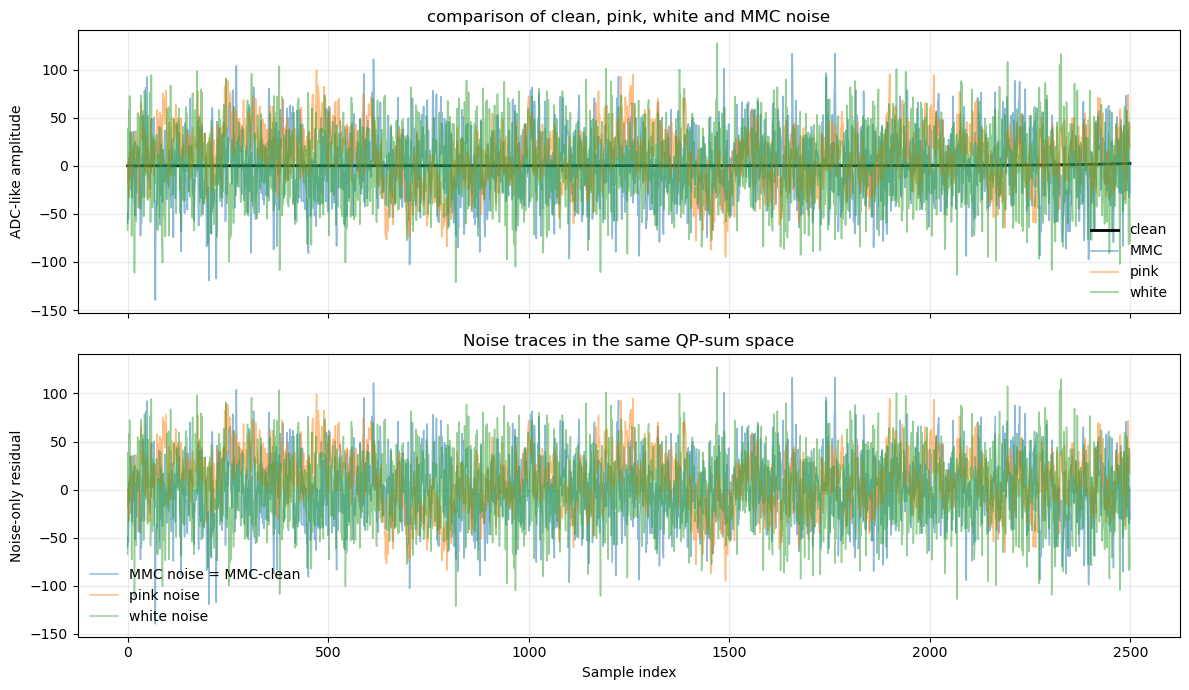

/tmp/ipykernel_3840889/3751204554.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(box_mean, labels=models, showfliers=False)
/tmp/ipykernel_3840889/3751204554.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(box_std, labels=models, showfliers=False)
/tmp/ipykernel_3840889/3751204554.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(box_area, labels=models, showfliers=False)


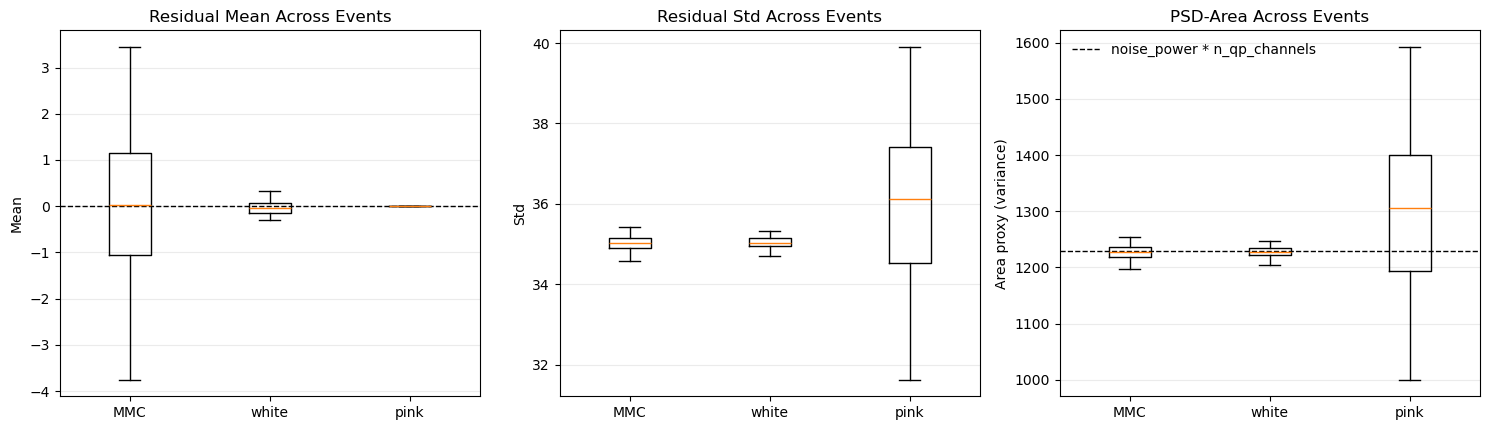

In [10]:
x = np.arange(clean.shape[1])
start = max(0, int(PLOT_START))
end = min(clean.shape[1], start + int(PLOT_SAMPLES))
win = slice(start, end)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# clean + noisy overlays (same random event)
axes[0].plot(x[win], clean[0, win], linewidth=2.0, color='black', label='clean')
axes[0].plot(x[win], mmc[0, win], linewidth=1.2, alpha=0.5, label='MMC')
axes[0].plot(x[win], noisy_pink[0, win], linewidth=1.2, alpha=0.5, label='pink')
axes[0].plot(x[win], noisy_white[0, win], linewidth=1.2, alpha=0.5, label='white')
axes[0].set_ylabel('ADC-like amplitude')
axes[0].set_title(f'comparison of clean, pink, white and MMC noise')
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.25)

# noise-only residuals
axes[1].plot(x[win], res_mmc[0, win], linewidth=1.1, alpha=0.5, label='MMC noise = MMC-clean')
axes[1].plot(x[win], res_p[0, win], linewidth=1.1, alpha=0.5, label='pink noise')
axes[1].plot(x[win], res_w[0, win], linewidth=1.1, alpha=0.5, label='white noise')
axes[1].set_xlabel('Sample index')
axes[1].set_ylabel('Noise-only residual')
axes[1].set_title('Noise traces in the same QP-sum space')
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


models = ['MMC', 'white', 'pink']
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

box_mean = [metric_df.loc[metric_df['model'] == m, 'mean'].values for m in models]
box_std = [metric_df.loc[metric_df['model'] == m, 'std'].values for m in models]
box_area = [metric_df.loc[metric_df['model'] == m, 'psd_area_proxy'].values for m in models]

axes[0].boxplot(box_mean, labels=models, showfliers=False)
axes[0].axhline(0.0, color='k', linestyle='--', linewidth=1.0)
axes[0].set_title('Residual Mean Across Events')
axes[0].set_ylabel('Mean')
axes[0].grid(alpha=0.25, axis='y')

axes[1].boxplot(box_std, labels=models, showfliers=False)
axes[1].set_title('Residual Std Across Events')
axes[1].set_ylabel('Std')
axes[1].grid(alpha=0.25, axis='y')

axes[2].boxplot(box_area, labels=models, showfliers=False)
axes[2].axhline(expected_sum_var, color='k', linestyle='--', linewidth=1.0, label='noise_power * n_qp_channels')
axes[2].set_title('PSD-Area Across Events')
axes[2].set_ylabel('Area proxy (variance)')
axes[2].grid(alpha=0.25, axis='y')
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()


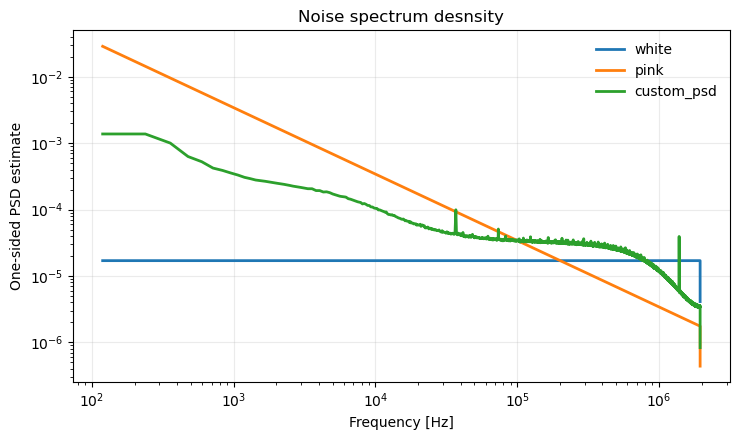

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))

labels = []
for nt in noise_types:
    labels.append(nt if nt in ['white', 'pink'] else 'custom_psd')

for nt, lab in zip(noise_types, labels):
    f, P = periodogram_one_sided(samples[nt], fs)
    Pm = np.mean(P, axis=0)
    ax.loglog(f[1:], Pm[1:], linewidth=2.0, label=lab)

ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('One-sided PSD estimate')
ax.set_title('Noise spectrum desnsity')
ax.grid(alpha=0.25)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


## Statistical conclusion from many residual samples

- Residuals are defined as `noise = noisy - clean` per event.
- Noise scale comparison is done with many-event statistics (`mean`, `std`, `var`, PSD-area proxy).
- PSD-area proxy is taken from time-domain variance, so no FFT integration is required for this scale check.
- This directly tests whether MMC / white / pink are on comparable scale in the same QP-sum space.
